In [39]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import json
import matplotlib.dates as mdates

In [40]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": -33.45,  # Latitud de Santiago
    "longitude": -70.65, # Longitud de Santiago
    "current_weather": True
}
response = requests.get(url, params=params)
response.raise_for_status()  # lanza excepcion si codigo >= 400
data = response.json()

print(f"Codigo de estado : {response.status_code}")
print(f"URL final : {response.url}")
print(f"Clima actual : {data['current_weather']}")

Codigo de estado : 200
URL final : https://api.open-meteo.com/v1/forecast?latitude=-33.45&longitude=-70.65&current_weather=True
Clima actual : {'time': '2026-06-10T15:30', 'interval': 900, 'temperature': 9.2, 'windspeed': 4.2, 'winddirection': 36, 'is_day': 1, 'weathercode': 53}


In [41]:
# Explorar el JSON antes de procesarlo
print("Claves principales:", list(data.keys()))

# Ver el JSON formateado
print(json.dumps(data, indent=4))

Claves principales: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_weather_units', 'current_weather']
{
    "latitude": -33.427067,
    "longitude": -70.64276,
    "generationtime_ms": 0.10859966278076172,
    "utc_offset_seconds": 0,
    "timezone": "GMT",
    "timezone_abbreviation": "GMT",
    "elevation": 554.0,
    "current_weather_units": {
        "time": "iso8601",
        "interval": "seconds",
        "temperature": "\u00b0C",
        "windspeed": "km/h",
        "winddirection": "\u00b0",
        "is_day": "",
        "weathercode": "wmo code"
    },
    "current_weather": {
        "time": "2026-06-10T15:30",
        "interval": 900,
        "temperature": 9.2,
        "windspeed": 4.2,
        "winddirection": 36,
        "is_day": 1,
        "weathercode": 53
    }
}


In [61]:
"""
al usar timeout=0.00001 la peticion casi siempre falla porque el tiempo de 
espera es demasiado corto para establecer la conexion y recibir una respuesta
la excepcion que normalmente se lanza es requests.exceptions.timeout
"""

'\nal usar timeout=0.00001 la peticion casi siempre falla porque el tiempo de \nespera es demasiado corto para establecer la conexion y recibir una respuesta\nla excepcion que normalmente se lanza es requests.exceptions.timeout\n'

In [62]:
"""
response.text entrega la respuesta como texto plano mientras que response.json() 
la transforma automaticamente en objetos de python como diccionarios o listas lo que hace mucho mas fasil 
acceder a los datos
"""

'\nresponse.text entrega la respuesta como texto plano mientras que response.json() \nla transforma automaticamente en objetos de python como diccionarios o listas lo que hace mucho mas fasil \nacceder a los datos\n'

In [63]:
"""
los parametros fueron agregados como query parameters dentro de la url
cada parametro aparece con el formato clave=valor y se separan usando el simbolo &
la libreria requests hizo esta conversion automaticamente a partir del diccionario params
"""

'\nlos parametros fueron agregados como query parameters dentro de la url\ncada parametro aparece con el formato clave=valor y se separan usando el simbolo &\nla libreria requests hizo esta conversion automaticamente a partir del diccionario params\n'

In [45]:
def get_seguro(url, params=None, timeout=10):
    """
    GET robusto con manejo de errores.
    Retorna el dict JSON o None si ocurre cualquier error.
    """

    try:
        r = requests.get(
            url,
            params=params,
            timeout=timeout
        )

        r.raise_for_status()
        return r.json()

    except requests.exceptions.Timeout:
        print(f"[ERROR] Timeout: la API no respondio en {timeout}s")

    except requests.exceptions.HTTPError as e:
        codigo = e.response.status_code
        print(f"[ERROR] HTTP {codigo}: {e.response.reason}")

        if codigo == 404:
            print("Endpoint no encontrado. Revisa la URL.")
        elif codigo == 429:
            print("Limite de peticiones excedido. Usar time.sleep().")
        elif codigo == 401:
            print("No autorizado. Verificar API key.")

    except requests.exceptions.ConnectionError:
        print("[ERROR] Sin conexion o host invalido")

    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Error inesperado: {e}")

    return None

In [64]:
# Caso 1: URL valida — debe retornar datos
r1 = get_seguro(
"https://api.open-meteo.com/v1/forecast",
params={"latitude": -33.45, "longitude": -70.65, "current_weather": True}
)
print("Caso 1 (valido):", r1["current_weather"] if r1 else "None")
# Caso 2: Endpoint inexistente — debe mostrar error 404
r2 = get_seguro("https://api.open-meteo.com/v1/ruta_invalida")
print("Caso 2 (404):", r2)
# Caso 3: Timeout muy bajo — debe mostrar error de timeout
r3 = get_seguro("https://api.open-meteo.com/v1/forecast", timeout=0.00001)
print("Caso 3 (timeout):", r3)

Caso 1 (valido): {'time': '2026-06-10T15:45', 'interval': 900, 'temperature': 9.5, 'windspeed': 3.9, 'winddirection': 24, 'is_day': 1, 'weathercode': 53}
[ERROR] Timeout: la API no respondio en 10s
Caso 2 (404): None
[ERROR] Timeout: la API no respondio en 1e-05s
Caso 3 (timeout): None


In [47]:
"""
a) ¿Por qué usar timeout?

Porque evita que el programa quede esperando indefinidamente si la API no responde.

b) ¿Qué hace raise_for_status()?

Verifica el código de respuesta HTTP y genera una excepción si ocurrió un error (404, 500, etc.).

c) ¿Cuándo usar cada excepción?

- Timeout: cuando la API tarda demasiado en responder.
- HTTPError: cuando el servidor devuelve un error HTTP.
- ConnectionError: cuando no se puede establecer conexión con el servidor.
- RequestException: para cualquier otro error relacionado con la petición.
"""

'\na) ¿Por qué usar timeout?\n\nPorque evita que el programa quede esperando indefinidamente si la API no responde.\n\nb) ¿Qué hace raise_for_status()?\n\nVerifica el código de respuesta HTTP y genera una excepción si ocurrió un error (404, 500, etc.).\n\nc) ¿Cuándo usar cada excepción?\n\n- Timeout: cuando la API tarda demasiado en responder.\n- HTTPError: cuando el servidor devuelve un error HTTP.\n- ConnectionError: cuando no se puede establecer conexión con el servidor.\n- RequestException: para cualquier otro error relacionado con la petición.\n'

In [48]:
"""
Un script sin timeout es peligroso porque puede quedar esperando indefinidamente si la API no responde o tiene problemas, 
bloqueando la ejecución del programa y consumiendo recursos innecesariamente.
"""

'\nUn script sin timeout es peligroso porque puede quedar esperando indefinidamente si la API no responde o tiene problemas, \nbloqueando la ejecución del programa y consumiendo recursos innecesariamente.\n'

In [66]:
"""
utilizaria reintentos usando time.sleep() para esperar unos segundos antes de volver a hacer la peticion
de esta forma si el error fue temporal la
solicitud podria llegar a completarse correctamente en un nuevo intento
"""

'\nutilizaria reintentos usando time.sleep() para esperar unos segundos antes de volver a hacer la peticion\nde esta forma si el error fue temporal la\nsolicitud podria llegar a completarse correctamente en un nuevo intento\n'

In [67]:
"""
connectionerror ocurre cuando no se puede establecer la conexion con el
servidor por ejemplo por falta de internet o porque la url no es valida
timeout ocurre cuando la conexion si se intenta realizar pero el servidor demora demasiado en responder y 
se supera el tiempo limite definido
"""

'\nconnectionerror ocurre cuando no se puede establecer la conexion con el\nservidor por ejemplo por falta de internet o porque la url no es valida\ntimeout ocurre cuando la conexion si se intenta realizar pero el servidor demora demasiado en responder y \nse supera el tiempo limite definido\n'

In [51]:
def consumir_paginado(url, limite=20, max_paginas=20):
    """
    Consume una API con paginacion tipo page+limit.
    Retorna lista con todos los registros.
    """

    todos = []
    pagina = 1

    while pagina <= max_paginas:

        resultado = get_seguro(
            url,
            params={"_page": pagina, "_limit": limite}
        )

        if resultado is None:
            break

        if not resultado:
            print(f"Fin de datos en pagina {pagina}")
            break

        todos.extend(resultado)

        print(
            f"Pagina {pagina:2d}: {len(resultado):3d} registros | Total: {len(todos)}"
        )

        pagina += 1

        time.sleep(0.1)

    return todos

In [52]:
print("Descargando posts...")
posts = consumir_paginado(
"https://jsonplaceholder.typicode.com/posts",
limite=20
)
df_posts = pd.DataFrame(posts)
print(f"\nForma del DataFrame: {df_posts.shape}")
print("\nPrimeras filas:")
print(df_posts.head())
print("\nTipos de datos:")
print(df_posts.dtypes)

Descargando posts...
Pagina  1:  20 registros | Total: 20
Pagina  2:  20 registros | Total: 40
Pagina  3:  20 registros | Total: 60
Pagina  4:  20 registros | Total: 80
Pagina  5:  20 registros | Total: 100
Fin de datos en pagina 6

Forma del DataFrame: (100, 4)

Primeras filas:
   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt s

In [53]:
# Estadisticas por userId
resumen = df_posts.groupby("userId").agg(
total_posts = ("id", "count"),
largo_promedio = ("body", lambda x: x.str.len().mean().round(1))
).reset_index()
print(resumen)
# Exportar a CSV
df_posts.to_csv("posts.csv", index=False)
resumen.to_csv("resumen_usuarios.csv", index=False)
print("\nArchivos CSV exportados correctamente.")

   userId  total_posts  largo_promedio
0       1           10           164.5
1       2           10           162.9
2       3           10           153.8
3       4           10           182.3
4       5           10           162.5
5       6           10           147.0
6       7           10           163.5
7       8           10           160.6
8       9           10           154.6
9      10           10           154.7

Archivos CSV exportados correctamente.


In [68]:
"""
si la api devuelve una lista vacia en la primera pagina el ciclo detectara que no hay datos disponibles
en ese caso mostrara el mensaje "fin de datos en pagina 1" 
y terminara la ejecucion sin descargar ningun registro
"""

'\nsi la api devuelve una lista vacia en la primera pagina el ciclo detectara que no hay datos disponibles\nen ese caso mostrara el mensaje "fin de datos en pagina 1" \ny terminara la ejecucion sin descargar ningun registro\n'

In [69]:
"""
el parametro max_paginas sirve para limitar la cantidad maxima de paginas que la funcion puede consultar
esto ayuda a evitar ciclos infinitos y tambien permite controlar 
la cantidad de solicitudes que se envian a la api
"""

'\nel parametro max_paginas sirve para limitar la cantidad maxima de paginas que la funcion puede consultar\nesto ayuda a evitar ciclos infinitos y tambien permite controlar \nla cantidad de solicitudes que se envian a la api\n'

In [70]:
"""
pd.DataFrame(lista_de_dicts) permite convertir automaticamente una lista de diccionarios en una tabla, 
creando las columnas y filas de forma automatica 
esto hace el codigo mas simple, rapido y facil de mantener que construir el DataFrame manualmente.
"""

'\npd.DataFrame(lista_de_dicts) permite convertir automaticamente una lista de diccionarios en una tabla, \ncreando las columnas y filas de forma automatica \nesto hace el codigo mas simple, rapido y facil de mantener que construir el DataFrame manualmente.\n'

In [36]:
def obtener_clima(lat, lon, dias=3):
    """Retorna DataFrame con temperatura horaria para una ubicacion."""

    data = get_seguro(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "hourly": "temperature_2m,precipitation_probability",
            "forecast_days": dias,
            "timezone": "America/Santiago"
        }
    )

    if data is None:
        return None

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])

    return df


CIUDADES = {
    "Santiago": (-33.45, -70.65),
    "Concepcion": (-36.82, -73.04),
    "Antofagasta": (-23.65, -70.40),
}

datos = {}

for ciudad, (lat, lon) in CIUDADES.items():
    print(f"Extrayendo {ciudad}...")
    datos[ciudad] = obtener_clima(lat, lon, dias=3)
    time.sleep(0.3)

print("Extraccion completa.")

Extrayendo Santiago...
Extrayendo Concepcion...
Extrayendo Antofagasta...
Extraccion completa.


In [37]:
frames = []

for ciudad, df in datos.items():
    if df is not None:
        df["ciudad"] = ciudad
        df["fecha"] = df["time"].dt.date
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

resumen_diario = df_all.groupby(
    ["ciudad", "fecha"]
).agg(
    temp_max=("temperature_2m", "max"),
    temp_min=("temperature_2m", "min"),
    temp_prom=("temperature_2m", "mean"),
).round(1).reset_index()

print(resumen_diario)

        ciudad       fecha  temp_max  temp_min  temp_prom
0  Antofagasta  2026-06-10      17.8      13.8       15.6
1  Antofagasta  2026-06-11      18.6      14.6       16.1
2  Antofagasta  2026-06-12      18.7      14.1       16.3
3   Concepcion  2026-06-10      13.4       7.4       10.8
4   Concepcion  2026-06-11      11.8       4.7        8.4
5   Concepcion  2026-06-12      11.6       8.5       10.4
6     Santiago  2026-06-10      11.5       7.1        8.9
7     Santiago  2026-06-11      16.0       3.4        9.6
8     Santiago  2026-06-12      19.1      10.6       13.9


CSV exportado: resumen_clima.csv


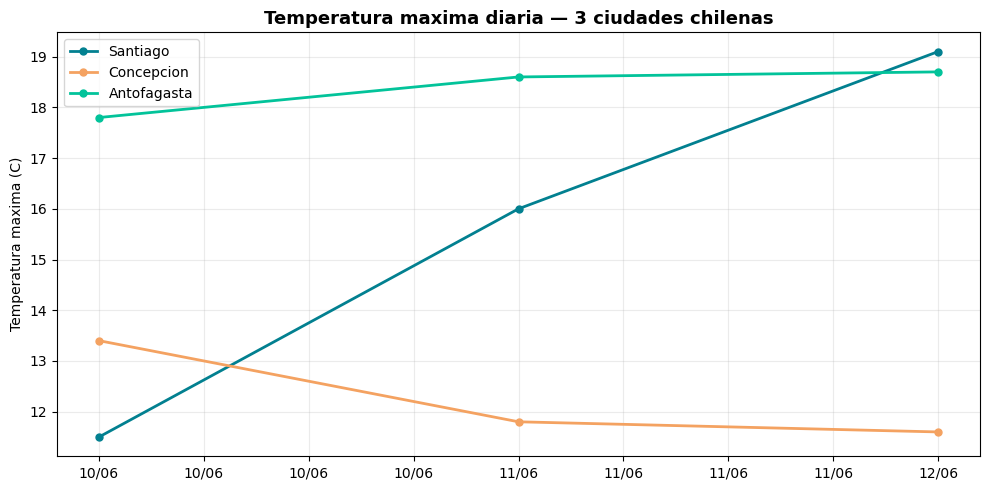

Grafico guardado: comparacion_temp.png


In [57]:
# Load
resumen_diario.to_csv("resumen_clima.csv", index=False)
print("CSV exportado: resumen_clima.csv")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))

colores = ["#028090", "#F4A261", "#02C39A"]

for (ciudad, color) in zip(CIUDADES.keys(), colores):
    df_c = resumen_diario[resumen_diario["ciudad"] == ciudad]
    fechas = pd.to_datetime(df_c["fecha"])

    ax.plot(
        fechas,
        df_c["temp_max"],
        marker="o",
        label=ciudad,
        color=color,
        linewidth=2,
        markersize=5
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

ax.set_title(
    "Temperatura maxima diaria — 3 ciudades chilenas",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel("Temperatura maxima (C)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("comparacion_temp.png", dpi=150, bbox_inches="tight")
plt.show()

print("Grafico guardado: comparacion_temp.png")

In [58]:
"""
Porque ajusta el diseño del gráfico y evita que elementos como títulos o etiquetas se corten al guardar la imagen. 
"""

'\nPorque ajusta el diseño del gráfico y evita que elementos como títulos o etiquetas se corten al guardar la imagen. \n'

In [71]:
"""
Solo habria que agregar una nueva ciudad al diccionario CIUDADES, ya que el resto del código la procesará automáticamente.
"""

'\nSolo habria que agregar una nueva ciudad al diccionario CIUDADES, ya que el resto del código la procesará automáticamente.\n'

In [60]:
"""
Primero extraje datos desde una API, luego los transformé con Pandas para obtener estadísticas y
finalmente los cargué exportándolos a archivos CSV y visualizándolos mediante un gráfico.
"""

'\nPrimero extraje datos desde una API, luego los transformé con Pandas para obtener estadísticas y\nfinalmente los cargué exportándolos a archivos CSV y visualizándolos mediante un gráfico.\n'